Nama: Roland Albertian Sehapikang  
Kelas: IF403  
Nim: 240401010294

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

titanic = sns.load_dataset('titanic')

print("--- Informasi Awal Dataset Titanic ---")
print(f"Jumlah Baris: {titanic.shape[0]} | Jumlah Kolom: {titanic.shape[1]}")
print(titanic[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']].head())

--- Informasi Awal Dataset Titanic ---
Jumlah Baris: 891 | Jumlah Kolom: 15
   survived  pclass     sex   age     fare embarked
0         0       3    male  22.0   7.2500        S
1         1       1  female  38.0  71.2833        C
2         1       3  female  26.0   7.9250        S
3         1       1  female  35.0  53.1000        S
4         0       3    male  35.0   8.0500        S


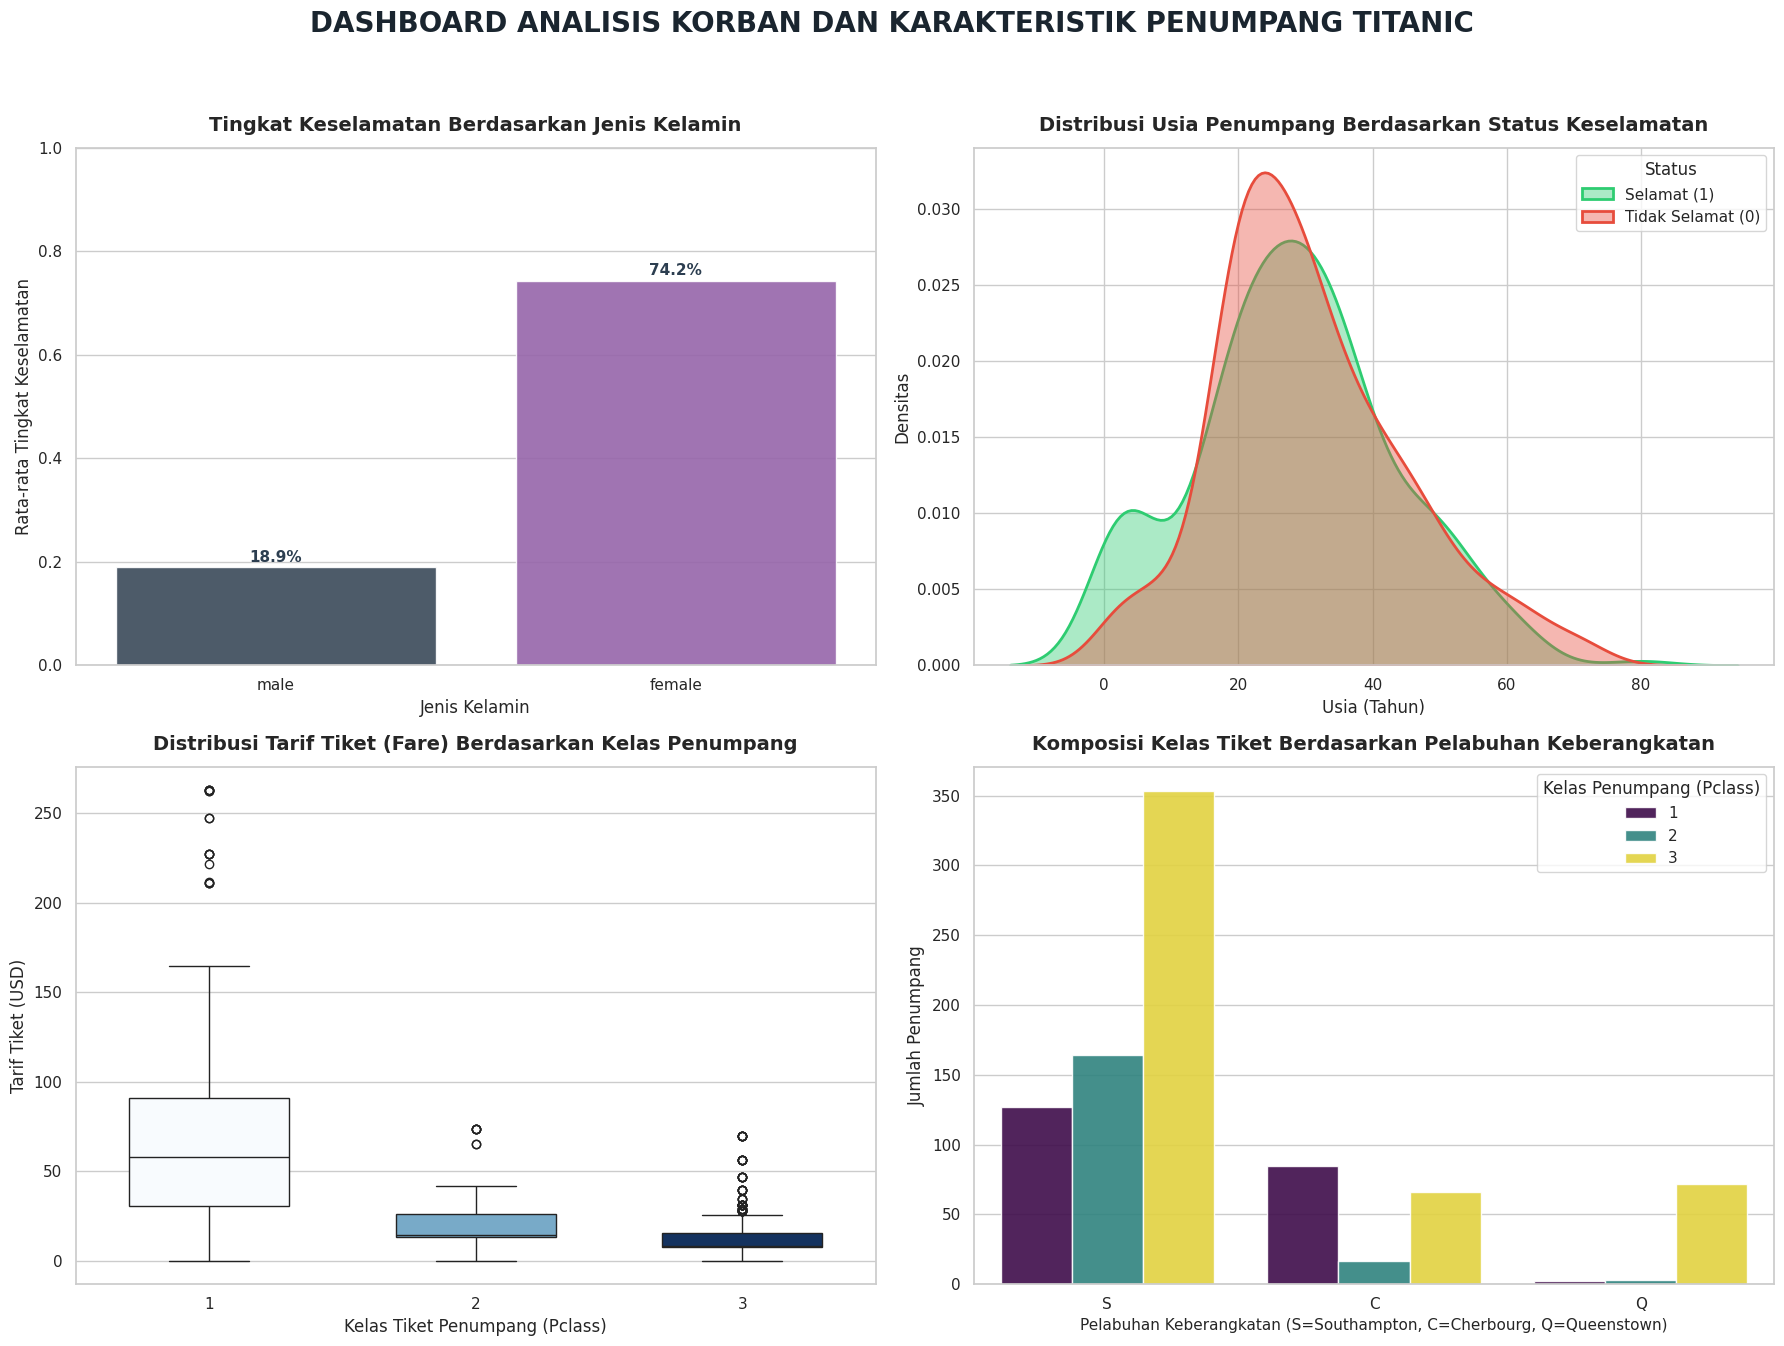

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

fig.suptitle('DASHBOARD ANALISIS KORBAN DAN KARAKTERISTIK PENUMPANG TITANIC',
             fontsize=20, fontweight='bold', color='#1a252f', y=0.96)

colors_survival = {0: "#e74c3c", 1: "#2ecc71"} # Merah = Tidak Selamat, Hijau = Selamat
palette_gender = {"male": "#34495e", "female": "#9b59b6"}
# -------------------------------------------------------------------------
# GRAPH 1 (Top-Left): Tingkat Keselamatan Berdasarkan Jenis Kelamin (Bar Chart)
# -------------------------------------------------------------------------
sns.barplot(data=titanic, x='sex', y='survived', hue='sex', legend=False,
            palette=palette_gender, errorbar=None, ax=axes[0, 0], alpha=0.9)
axes[0, 0].set_title('Tingkat Keselamatan Berdasarkan Jenis Kelamin', fontsize=14, fontweight='bold', pad=12)
axes[0, 0].set_xlabel('Jenis Kelamin', fontsize=12)
axes[0, 0].set_ylabel('Rata-rata Tingkat Keselamatan', fontsize=12)
axes[0, 0].set_ylim(0, 1)

for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height()*100:.1f}%",
                        (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
                        ha='center', va='center', fontsize=11, fontweight='bold', color='#2c3e50')

# -------------------------------------------------------------------------
# GRAPH 2 (Top-Right): Distribusi Usia Berdasarkan Status Keselamatan (KDE Plot)
# -------------------------------------------------------------------------
sns.kdeplot(data=titanic, x='age', hue='survived', palette=colors_survival,
            fill=True, common_norm=False, alpha=0.4, linewidth=2, ax=axes[0, 1])
axes[0, 1].set_title('Distribusi Usia Penumpang Berdasarkan Status Keselamatan', fontsize=14, fontweight='bold', pad=12)
axes[0, 1].set_xlabel('Usia (Tahun)', fontsize=12)
axes[0, 1].set_ylabel('Densitas', fontsize=12)
axes[0, 1].legend(title="Status", labels=["Selamat (1)", "Tidak Selamat (0)"], loc='upper right')

# -------------------------------------------------------------------------
# GRAPH 3 (Bottom-Left): Distribusi Tarif Tiket per Kelas Penumpang (Box Plot)
# -------------------------------------------------------------------------
sns.boxplot(data=titanic[titanic['fare'] <= 300], x='pclass', y='fare', hue='pclass', legend=False,
            palette='Blues', ax=axes[1, 0], width=0.6)
axes[1, 0].set_title('Distribusi Tarif Tiket (Fare) Berdasarkan Kelas Penumpang', fontsize=14, fontweight='bold', pad=12)
axes[1, 0].set_xlabel('Kelas Tiket Penumpang (Pclass)', fontsize=12)
axes[1, 0].set_ylabel('Tarif Tiket (USD)', fontsize=12)

# -------------------------------------------------------------------------
# GRAPH 4 (Bottom-Right): Jumlah Penumpang Berdasarkan Pelabuhan Keberangkatan (Count Plot)
# -------------------------------------------------------------------------
sns.countplot(data=titanic, x='embarked', hue='pclass', palette='viridis', ax=axes[1, 1], alpha=0.9)
axes[1, 1].set_title('Komposisi Kelas Tiket Berdasarkan Pelabuhan Keberangkatan', fontsize=14, fontweight='bold', pad=12)
axes[1, 1].set_xlabel('Pelabuhan Keberangkatan (S=Southampton, C=Cherbourg, Q=Queenstown)', fontsize=11)
axes[1, 1].set_ylabel('Jumlah Penumpang', fontsize=12)
axes[1, 1].legend(title="Kelas Penumpang (Pclass)", loc='upper right')


plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Interpretasi Wawasan Menggunakan Pendekatan "What? So what? Now what?"

### 1. Grafik Batang: Keselamatan Berdasarkan Jenis Kelamin
* **What?** Grafik menunjukkan ketimpangan masif pada tingkat keselamatan. Sebanyak 74.2% penumpang wanita berhasil selamat, sementara pria hanya mencatatkan angka keselamatan sebesar 18.9%.
* **So what?** Data historis ini mengonfirmasi secara mutlak bahwa aturan maritim evakuasi darurat, yaitu *"Women and children first"* (Wanita dan anak-anak didahulukan), dipatuhi dengan sangat ketat selama proses penyelamatan kapal Titanic.
* **Now what?** Dalam pemodelan prediktif klasifikasi menggunakan Machine Learning kelak, fitur variabel `sex` dipastikan akan menjadi prediktor yang sangat kuat (*high feature importance*) untuk menentukan probabilitas keselamatan penumpang.

### 2. Grafik KDE: Distribusi Usia vs Status Keselamatan
* **What?** Kurva densitas memperlihatkan adanya lonjakan kelolosan hidup yang signifikan pada kelompok usia anak-anak (rentang usia 0 hingga 10 tahun). Di sisi lain, kelompok usia produktif (20-40 tahun) memiliki grafik kematian (warna merah) yang dominan tinggi.
* **So what?** Anak-anak diprioritaskan bersama wanita untuk menaiki sekoci penyelamat terlebih dahulu, sedangkan mayoritas orang dewasa terpaksa tertinggal di kapal yang tenggelam.
* **Now what?** Sebelum melatih model prediktif, kita disarankan melakukan *feature engineering* berupa pengelompokan usia (*binning*) ke dalam kategori nominal, seperti 'Anak-anak', 'Dewasa', dan 'Lansia' agar model dapat menangkap pola non-linear ini secara lebih efisien.

### 3. Grafik Box Plot: Tarif Tiket Berdasarkan Kelas Penumpang
* **What?** Penumpang tiket Kelas 1 membayar tarif dengan rentang nilai yang sangat luas, fluktuatif, serta memiliki median tarif jauh di atas Kelas 2 dan Kelas 3. Box plot untuk Kelas 3 menunjukkan distribusi yang sangat rapat dan murah.
* **So what?** Terjadi ketimpangan daya beli dan status ekonomi yang ekstrem di antara kelompok penumpang kapal Titanic.
* **Now what?** Karena sebaran tarif (`fare`) pada Kelas 1 memiliki variansi serta kemiringan distribusi yang tinggi (*highly skewed*), proses prapemrosesan data (*data preprocessing*) berupa transformasi logaritma atau penskalaan dengan `RobustScaler` sangat direkomendasikan agar algoritma machine learning berbasis jarak tidak terganggu oleh pencilan tarif tersebut.

### 4. Grafik Count Plot: Komposisi Kelas Properti per Pelabuhan Asal
* **What?** Pelabuhan Southampton (S) merupakan lokasi keberangkatan dengan volume penumpang terbesar, didominasi oleh kelas bawah (Kelas 3). Sebaliknya, pelabuhan Cherbourg (C) memiliki proporsi keberangkatan Kelas 1 yang jauh lebih kompetitif jika dibandingkan kelas lainnya.
* **So what?** Karakteristik sosio-ekonomi penduduk bervariasi secara geografis berdasarkan lokasi pelabuhan keberangkatan mereka. Cherbourg kemungkinan merupakan kawasan elit perkotaan atau pusat perdagangan saat itu.
* **Now what?** Variabel kategorikal `embarked` memiliki korelasi tidak langsung terhadap status kelas sosial ekonomi penumpang (`pclass`). Kita harus melakukan pengisian data hilang (*imputasi*) pada kolom pelabuhan yang kosong menggunakan nilai modus (yaitu 'S') sebelum menerapkan teknik *One-Hot Encoding*.

# **Kesimpulan Singkat:**

**1. Apa yang Dipelajari?**
* **Pembuatan Dashboard Statis:** Mempelajari cara menggabungkan beberapa grafik menjadi satu tampilan (grid layout 2x2) menggunakan fungsi plt.subplots() dari Matplotlib.

* **Variasi Visualisasi Seaborn:** Menerapkan berbagai jenis grafik yang sesuai dengan tujuan analisis, seperti Bar Plot (perbandingan kategori), KDE Plot (distribusi/densitas), Box Plot (sebaran dan outlier), serta Count Plot (frekuensi data kategorikal).

* **Prinsip Estetika & Konteks:** Mengkustomisasi palet warna, menambahkan anotasi (seperti persentase di atas batang grafik), memberikan judul utama (suptitle), serta mengatur label sumbu X dan Y agar visualisasi mudah dipahami oleh audiens.

* **Data Storytelling:** Mempraktikkan kerangka narasi "What? So what? Now what?" untuk menerjemahkan grafik visual menjadi wawasan bisnis atau langkah analitik (actionable insights) selanjutnya.

**2. Temuan Utama**
* **Prioritas Evakuasi:** Grafik batang dan KDE secara visual membuktikan kebenaran sejarah bahwa wanita dan anak-anak balita mendapat prioritas utama untuk diselamatkan (tingkat keselamatan wanita mencapai 74.2%).

* **Ketimpangan Sosial Ekonomi:** Box plot memperlihatkan rentang tarif tiket (Fare) Kelas 1 yang sangat fluktuatif dan mahal, berbanding terbalik dengan Kelas 3 yang sangat padat dan murah.

* **Demografi Pelabuhan:** Count plot mengungkap bahwa Pelabuhan Southampton didominasi oleh penumpang pekerja/kelas bawah (Kelas 3), sementara Pelabuhan Cherbourg melayani proporsi penumpang elit (Kelas 1) yang lebih tinggi secara persentase.

**3. Keterbatasan atau Pertanyaan yang muncul**
* **Keterbatasan Visualisasi:** Dashboard ini bersifat statis. Audiens tidak bisa berinteraksi dengan grafik (misalnya melakukan hover untuk melihat angka pasti, melakukan zoom, atau memfilter data berdasarkan rentang usia tertentu). Selain itu, untuk membuat box plot terlihat jelas, kita harus memotong (filter) data tarif ekstrem di atas 300 USD, yang berarti ada informasi outlier yang disembunyikan.
* **Pertanyaan yang Muncul:**
  * Bagaimana cara kita mengubah dashboard statis Matplotlib/Seaborn ini menjadi dashboard yang interaktif menggunakan library seperti Plotly atau Streamlit?

  * Jika kita ingin melihat tingkat keselamatan kombinasi antara 3 variabel sekaligus (misal: Wanita AND Kelas 3 AND dari pelabuhan Southampton), visualisasi jenis apa yang paling efektif agar grafik tidak terlihat menumpuk dan membingungkan?